# Data Scaling in Neural Network

# Import Libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [40]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

In [41]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD, Adam
from keras.activations import sigmoid
from keras.losses import BinaryCrossentropy

# Make Dataset

In [42]:
df = pd.DataFrame(
    data={
        'x1': np.random.randint(0, 10, 100),
        'x2': np.random.randint(10000, 100000, 100),
        'y': np.random.randint(0, 2, 100)
    }
)

In [43]:
df.head()

,x1,x2,y
0,2,87054,0
1,2,10944,0
2,4,51661,0
3,2,10835,0
4,2,63885,1


# Plot Dataset

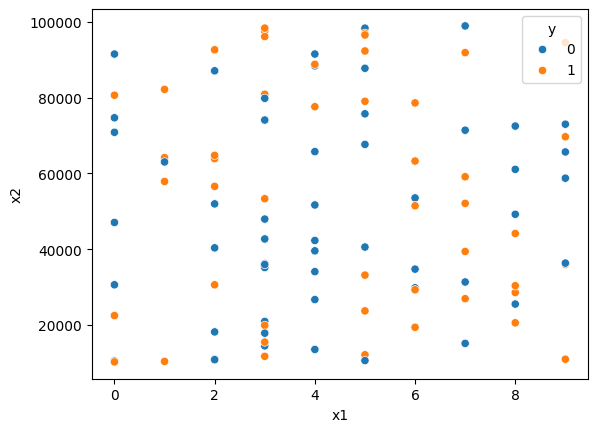

In [44]:
sns.scatterplot(data=df, x='x1', y='x2', hue='y')
plt.show()

# Train Test Split

In [45]:
X = df[['x1', 'x2']]
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Unnormalized Model Building

In [46]:
unnormalized_model = Sequential()
unnormalized_model.add(Input(shape=(2,)))
unnormalized_model.add(Dense(10, activation='relu'))
unnormalized_model.add(Dense(1, activation='sigmoid'))

In [47]:
unnormalized_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [48]:
unnormalized_model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

## Model Training

In [49]:
history = unnormalized_model.fit(
    x=X_train,
    y=y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5422 - loss: 5145.8364 - val_accuracy: 0.5000 - val_loss: 5072.7163
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5500 - loss: 4839.4136 - val_accuracy: 0.5000 - val_loss: 4654.6157
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4992 - loss: 4720.0527 - val_accuracy: 0.5000 - val_loss: 4241.0146
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5539 - loss: 3844.5708 - val_accuracy: 0.5000 - val_loss: 3835.4585
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5031 - loss: 3680.9214 - val_accuracy: 0.5000 - val_loss: 3423.5149
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5383 - loss: 3240.1021 - val_accuracy: 0.5000 - val_loss: 3015.6030
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5305 - loss: 2906.9146 - val_accuracy: 0.5000 - val_loss: 2611.6748
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5227 - loss: 2360.9

## History Plot

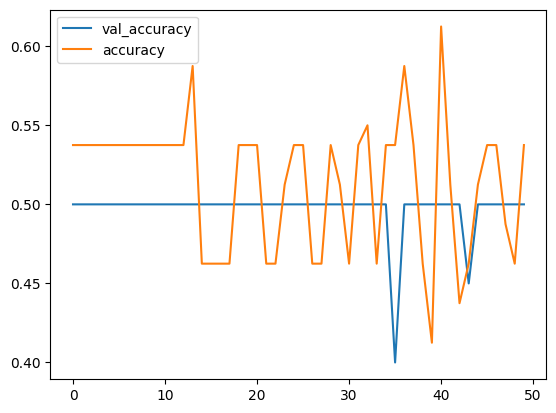

In [50]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.legend(['val_accuracy', 'accuracy'])
plt.show()

# Normalized Model

In [51]:
X_train.head()

,x1,x2
55,4,77586
88,5,92286
26,0,70829
42,5,23709
69,4,39553


## Standard Scale

In [53]:
std_scale = StandardScaler()
norm_scale = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['x1'] = norm_scale.fit_transform(X_train[['x1']])
X_train_scaled['x2'] = std_scale.fit_transform(X_train[['x2']])

X_test_scaled['x1'] = norm_scale.transform(X_test[['x1']])
X_test_scaled['x2'] = std_scale.transform(X_test[['x2']])

In [54]:
X_test_scaled.head()

,x1,x2
83,0.111111,-1.461198
53,0.666667,-1.132132
70,0.555556,1.047091
45,0.000000,-0.121178
44,0.888889,0.808378


## Plot Scaled Data

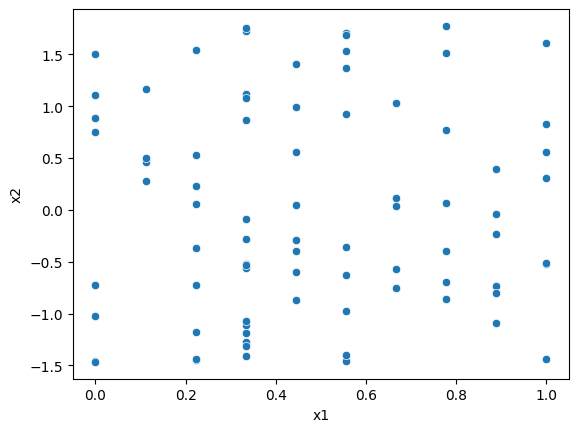

In [57]:
sns.scatterplot(x=X_train_scaled['x1'], y=X_train_scaled['x2'])
plt.show()

## Model Build

In [58]:
normalized_model = Sequential()
normalized_model.add(Input(shape=(2,)))
normalized_model.add(Dense(10, activation='relu'))
normalized_model.add(Dense(1, activation='sigmoid'))

In [59]:
normalized_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [60]:
normalized_model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

## Model Trainning

In [61]:
history2 = normalized_model.fit(
    x=X_train_scaled,
    y=y_train,
    epochs=50,
    validation_data=(X_test_scaled, y_test)
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 441ms/step - accuracy: 0.5383 - loss: 0.6985 - val_accuracy: 0.5000 - val_loss: 0.7275
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5383 - loss: 0.6987 - val_accuracy: 0.5000 - val_loss: 0.7272
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5617 - loss: 0.6876 - val_accuracy: 0.5000 - val_loss: 0.7270
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5148 - loss: 0.7089 - val_accuracy: 0.5000 - val_loss: 0.7269
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5023 - loss: 0.7009 - val_accuracy: 0.5000 - val_loss: 0.7269
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5148 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.7270
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5320 - loss: 0.6835 - val_accuracy: 0.5000 - val_loss: 0.7273
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4992 - loss: 0.7055 - val_accuracy: 0.5000 - val_loss: 0.7

## History Plot

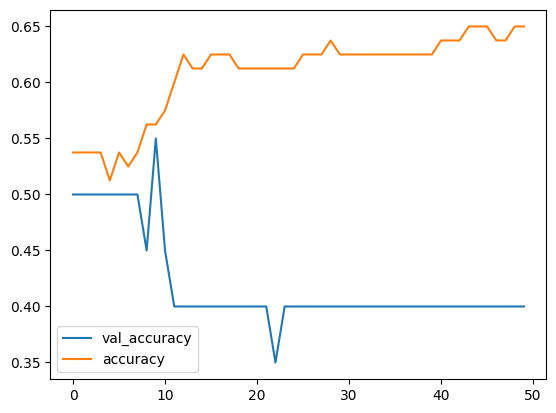

In [62]:
plt.plot(history2.history['val_accuracy'])
plt.plot(history2.history['accuracy'])
plt.legend(['val_accuracy', 'accuracy'])
plt.show()